# Stochastic Interest Rate Modelling: CIR Implementation

This notebook implements, calibrates, and extends the Cox-Ingersoll-Ross (1985) short-rate model on historical zero-coupon yield data. The CIR model describes the evolution of the instantaneous short rate $r_t$ via the stochastic differential equation:

$$dr_t = \kappa(\theta - r_t) \, dt + \sigma\sqrt{r_t} \, dW_t$$

where $\kappa > 0$ is the speed of mean reversion, $\theta > 0$ is the long-run equilibrium rate, $\sigma > 0$ is the volatility coefficient, and $W_t$ is a standard Brownian motion. The defining feature is the square-root diffusion term $\sigma\sqrt{r_t}$: it causes volatility to shrink as $r_t \to 0$, which — provided the Feller condition $2\kappa\theta \geq \sigma^2$ holds — prevents the process from ever reaching zero. This makes CIR fundamentally more suitable for macroeconomic modelling than the Vasicek model, which allows negative rates.

The notebook proceeds in five stages: data preprocessing, model implementation and calibration, out-of-sample prediction, a CIR++ extension, and a critical analysis of both models.

In [7]:
# ==============================================================================
# SETUP & GLOBAL IMPORTS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize          # L-BFGS-B solver for MLE calibration
from sklearn.metrics import r2_score, mean_squared_error
import warnings
import time

warnings.simplefilter(action='ignore', category=FutureWarning)

# ------------------------------------------------------------------------------
# Global Constants
# ------------------------------------------------------------------------------

# FULL_MATURITIES: the 9 tenor points (in years) the CIR model must reproduce.
# 0.25 = 3M, 0.5 = 6M, 0.75 = 9M, 1 = 1Y, 2 = 2Y, 5 = 5Y, 10 = 10Y, 20 = 20Y, 30 = 30Y
FULL_MATURITIES = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

# MATURITY_MAP: maps raw CSV column names to their maturity in years.
# Used to align DataFrame columns with the mathematical τ (tau) values.
MATURITY_MAP = {
    'ZC025YR': 0.25, 'ZC050YR': 0.5,  'ZC075YR': 0.75,
    'ZC100YR': 1.0,  'ZC200YR': 2.0,  'ZC500YR': 5.0,
    'ZC1000YR': 10.0, 'ZC2000YR': 20.0, 'ZC3000YR': 30.0
}

# MATURITY_LABELS: human-readable strings for plots and diagnostic tables.
MATURITY_LABELS = {
    0.25: '3M', 0.5: '6M', 0.75: '9M', 1.0: '1Y',
    2.0: '2Y', 5.0: '5Y', 10.0: '10Y', 20.0: '20Y', 30.0: '30Y'
}


## Part 5.1 — Data Engineering and Preprocessing

Raw yield data from financial markets is rarely clean. The dataset spans daily observations across nine maturity tenors (3M, 6M, 9M, 1Y, 2Y, 5Y, 10Y, 20Y, 30Y) and requires four preprocessing steps before it can be used for stochastic calibration.

**Step 1 — Weekend removal.** Bond markets do not trade on weekends. Any Saturday or Sunday rows represent either data-entry errors or carry-forwards from Friday, and including them would artificially inflate the observation count and distort the time step $dt = 1/252$ assumed by the Kalman Filter.

**Step 2 — Missing value imputation.** Gaps are filled via forward-fill (propagating the last valid observation), followed by backward-fill for any leading NaNs, and finally time-interpolation for isolated mid-series gaps. This preserves the continuous time-series structure required by the Euler-Maruyama discretisation in the Kalman Filter.

**Step 3 — Outlier replacement.** A 20-day centre-aligned rolling window is used to compute a local median and standard deviation at each date. Any observation more than $3\sigma$ away from the local median is replaced by that median. Outliers are replaced rather than dropped to maintain the fixed-length panel required by the KF recursion. A window of 20 days is long enough to define a stable local distribution but short enough to track genuine regime shifts.

**Step 4 — Positivity floor.** The CIR diffusion term $\sigma\sqrt{r_t}$ is only real-valued for $r_t \geq 0$. All yields are clipped to a minimum of $0.0001$ (1 basis point) to prevent domain errors in `np.sqrt` while remaining economically sensible.

--- STARTING PART 5.1: DATA ENGINEERING ---
[EDA] Raw dataset shapes:
  Train:    (1976, 9)   (2016-05-19 → 2024-04-26)
  Test:     (495, 5)    (2024-04-29  → 2026-04-29)
  Test-3M:  (495, 1)

[EDA] Missing values per column (Training Set):
  None found.

[EDA] Outliers detected per column (Training Set, 3σ rolling window):
ZC025YR     1
ZC050YR     2
ZC075YR     1
ZC100YR     0
ZC200YR     2
ZC500YR     2
ZC1000YR    1
ZC2000YR    2
ZC3000YR    2


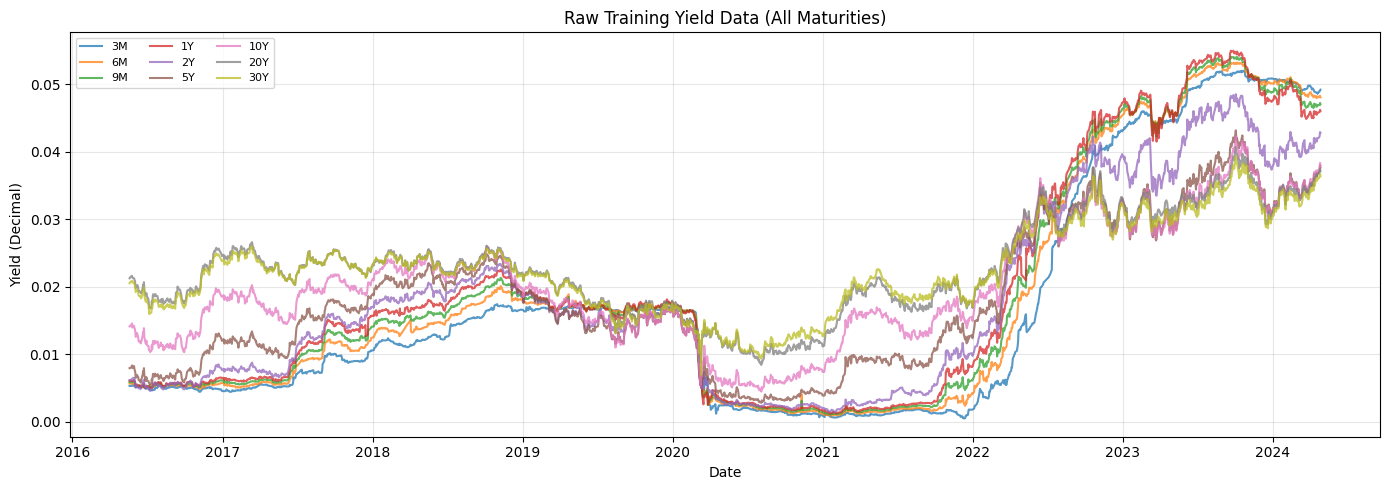


Preprocessing complete. Train shape: (1976, 9), Test shape: (495, 5)



In [8]:
# ==============================================================================
# PART 5.1: DATA ENGINEERING AND PREPROCESSING
# ==============================================================================
print("--- STARTING PART 5.1: DATA ENGINEERING ---")


def preprocess_data(train_path, test_path, test_3m_path):
    """
    Load, inspect, and clean all three CSV files.

    Steps applied in order:
      1. Remove weekend rows (non-trading days).
      2. Impute missing values via forward-fill → backward-fill → time interpolation.
      3. Replace rolling-window outliers with the local median.
      4. Clip all values to a small positive floor (required by CIR square-root diffusion).

    Parameters
    ----------
    train_path   : path to the full training CSV
    test_path    : path to the full test CSV  (all maturities)
    test_3m_path : path to the 3M-only test CSV used as the short-rate proxy

    Returns
    -------
    train_clean, test_clean, test_3m_clean : cleaned DataFrames (Date index)
    """
    # --- Load raw CSVs ---
    try:
        train_df   = pd.read_csv(train_path)
        test_df    = pd.read_csv(test_path)
        test_3m_df = pd.read_csv(test_3m_path)
    except FileNotFoundError as e:
        print(f"Error loading files: {e}")
        return None, None, None

    # Standardise column names, parse dates, and sort chronologically for all DFs
    for df in [train_df, test_df, test_3m_df]:
        df.columns = df.columns.str.strip()        # strip any accidental whitespace
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        df.sort_index(inplace=True)                # ensure strictly ascending time order

    # ------------------------------------------------------------------
    # EDA DIAGNOSTICS — run on raw (uncleaned) data for transparency
    # ------------------------------------------------------------------
    print("[EDA] Raw dataset shapes:")
    print(f"  Train:    {train_df.shape}   ({train_df.index.min().date()} → {train_df.index.max().date()})")
    print(f"  Test:     {test_df.shape}    ({test_df.index.min().date()}  → {test_df.index.max().date()})")
    print(f"  Test-3M:  {test_3m_df.shape}")

    print("\n[EDA] Missing values per column (Training Set):")
    missing = train_df.isnull().sum()
    print(missing.to_string() if missing.any() else "  None found.")

    # Count outliers using the same 3σ rolling rule applied in cleaning below,
    # so that the diagnostic figure is directly comparable to the cleaning step.
    def _count_outliers(df):
        rm = df.rolling(window=20, min_periods=1, center=True).median()
        rs = df.rolling(window=20, min_periods=1, center=True).std()
        # A value is an outlier if it deviates by more than 3 standard deviations
        # from the local 20-day rolling median (centre-aligned window).
        return ((df > rm + 3 * rs) | (df < rm - 3 * rs)).sum()

    train_outliers = _count_outliers(train_df.select_dtypes(include=np.number))
    print("\n[EDA] Outliers detected per column (Training Set, 3σ rolling window):")
    print(train_outliers.to_string() if train_outliers.any() else "  None found.")

    # Plot raw yield time-series for a visual sanity check
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in train_df.columns:
        if col in MATURITY_MAP:
            ax.plot(train_df.index, train_df[col],
                    alpha=0.75, label=MATURITY_LABELS[MATURITY_MAP[col]])
    ax.set_title("Raw Training Yield Data (All Maturities)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Yield (Decimal)")
    ax.legend(ncol=3, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # ------------------------------------------------------------------

    # --- Step 1: Remove non-trading days (weekends) ---
    # dayofweek: Monday=0, ..., Friday=4, Saturday=5, Sunday=6
    # Keeping only < 5 removes Saturday and Sunday.
    train_df   = train_df[train_df.index.dayofweek < 5]
    test_df    = test_df[test_df.index.dayofweek < 5]
    test_3m_df = test_3m_df[test_3m_df.index.dayofweek < 5]

    # --- Step 2: Impute missing values ---
    # Forward-fill first (propagates the last valid observation forward),
    # then backward-fill for any leading NaNs at the start of the series,
    # then time-interpolation for any remaining gaps in the middle.
    train_df   = train_df.ffill().bfill().interpolate(method='time')
    test_df    = test_df.ffill().bfill().interpolate(method='time')
    test_3m_df = test_3m_df.ffill().bfill().interpolate(method='time')

    # --- Step 3: Outlier detection and replacement ---
    def clean_outliers(df):
        """
        Replace extreme values with the local 20-day rolling median.

        Method: centre-aligned rolling statistics over a 20-business-day window.
          - rolling_median: local 'expected' level of the yield
          - rolling_std:    local spread / noise level
        A value is flagged as an outlier if it falls outside [median ± 3·std].
        Outliers are replaced by the rolling median at that date (not dropped),
        preserving the time-series length needed for Kalman Filter recursion.
        The trailing ffill() handles any residual NaNs from the mask operation.
        """
        rolling_median = df.rolling(window=20, min_periods=1, center=True).median()
        rolling_std    = df.rolling(window=20, min_periods=1, center=True).std()
        # Boolean mask: True wherever the raw value is anomalously far from local median
        is_outlier = (df > rolling_median + 3 * rolling_std) | \
                     (df < rolling_median - 3 * rolling_std)
        # Replace outlier cells with the rolling median; non-outlier cells are unchanged
        return df.mask(is_outlier, rolling_median).ffill()

    train_df   = clean_outliers(train_df)
    test_df    = clean_outliers(test_df)
    test_3m_df = clean_outliers(test_3m_df)

    # --- Step 4: Enforce strict positivity ---
    # The CIR diffusion term σ√r_t requires r_t > 0 at all times.
    # Clipping to 0.0001 (1 basis point) prevents domain errors in np.sqrt
    # while keeping values economically sensible.
    train_df   = train_df.clip(lower=0.0001)
    test_df    = test_df.clip(lower=0.0001)
    test_3m_df = test_3m_df.clip(lower=0.0001)

    print(f"\nPreprocessing complete. Train shape: {train_df.shape}, Test shape: {test_df.shape}\n")
    return train_df, test_df, test_3m_df


# Execute Part 5.1
train_clean, test_clean, test_3m_clean = preprocess_data(
    'train_data.csv', 'test_data.csv', 'test_data_3M.csv'
)

## Part 5.2 — Base CIR Model Implementation and Calibration

### Bond Pricing via the Affine Term Structure

From the CIR SDE, the price at time $t$ of a zero-coupon bond maturing at $T$ can be derived in closed form using the Feynman-Kac theorem. The solution has the affine exponential form:

$$P(t, T) = A(\tau) \, e^{-B(\tau) \, r_t}, \qquad \tau = T - t$$

where the deterministic functions $A(\tau)$ and $B(\tau)$ are obtained by solving the Riccati ODE that arises from the no-arbitrage bond pricing PDE. Defining the auxiliary constant $h = \sqrt{\kappa^2 + 2\sigma^2}$:

$$B(\tau) = \frac{2(e^{h\tau} - 1)}{2h + (\kappa + h)(e^{h\tau} - 1)}$$

$$A(\tau) = \left[\frac{2h \, e^{(\kappa + h)\tau/2}}{2h + (\kappa + h)(e^{h\tau} - 1)}\right]^{2\kappa\theta/\sigma^2}$$

The exponent $2\kappa\theta/\sigma^2$ is the degrees-of-freedom parameter of the non-central chi-squared distribution that governs $r_t$. The continuously compounded yield is then:

$$y(r_t, \tau) = \frac{B(\tau) \, r_t - \ln A(\tau)}{\tau}$$

This is the **affine property** of CIR: the yield is a linear function of $r_t$ for any fixed $\tau$. It directly justifies the prediction approach in Part 5.3 — observing the 3M yield uniquely pins down $r_t$, from which all other maturities can be reconstructed deterministically.

### Calibration: Kalman Filter Maximum Likelihood Estimation

The instantaneous short rate $r_t$ is not directly observable. The model is cast as a state-space system where $r_t$ is the latent state and the observed nine-tenor yield panel forms the measurement vector. The observation equation is exactly linear in $r_t$ by the affine property above, so the standard linear Kalman Filter applies without approximation.

The state transition is discretised via Euler-Maruyama with $dt = 1/252$:

$$r_{t+dt} \approx r_t + \kappa(\theta - r_t) \, dt + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \, \sigma^2 r_t \, dt)$$

At each time step the KF performs a **predict step** — propagating the state and its uncertainty forward — and an **update step** — correcting using the innovation, which is the gap between observed and predicted yields. Formally, the observation and transition equations are:

$$y_i(t) = H_i \cdot r_t + Z_i + \varepsilon_i, \qquad H_i = \frac{B(\tau_i)}{\tau_i}, \quad Z_i = \frac{-\ln A(\tau_i)}{\tau_i}$$

The innovation covariance is $F_t = H P_t H^\top + R$, the Kalman gain is $K_t = P_t H F_t^{-1}$, and the Gaussian log-likelihood accumulated across all $N$ days is:

$$\mathcal{L} = -\frac{1}{2} \sum_{t=1}^{N} \left[ \ln |F_t| + v_t^\top F_t^{-1} v_t \right]$$

where $v_t = y_t^{\text{obs}} - y_t^{\text{pred}}$ is the innovation vector. This quantity is maximised over $(\kappa, \theta, \sigma)$ using the L-BFGS-B optimiser.

--- STARTING PART 5.2: BASE CIR CALIBRATION ---
Running Kalman Filter calibration (standard linear KF)...
Calibration Success (11.41s) | κ: 0.1364, θ: 0.0249, σ: 0.0386

Feller Condition check: 2κθ = 0.006801,  σ² = 0.001488
  Status: ✓ SATISFIED — interest rates cannot reach zero under these parameters.

[Base CIR] In-Sample R²:   0.9212
[Base CIR] In-Sample RMSE: 0.003758



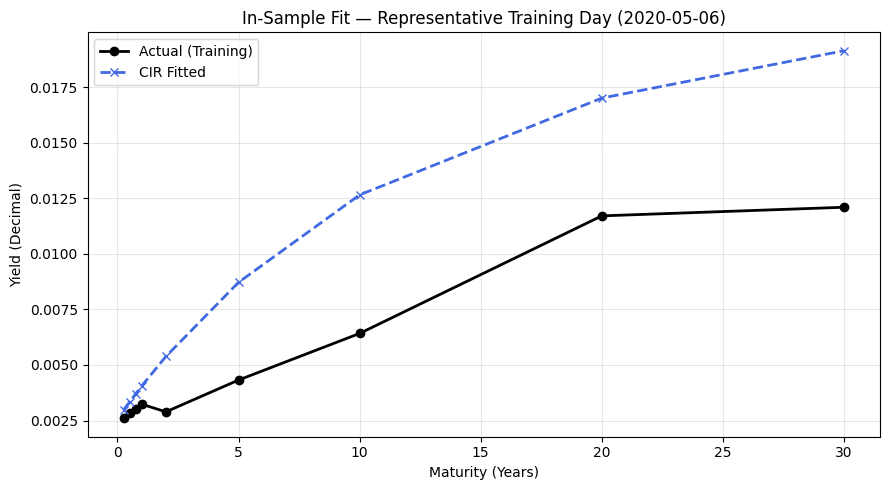

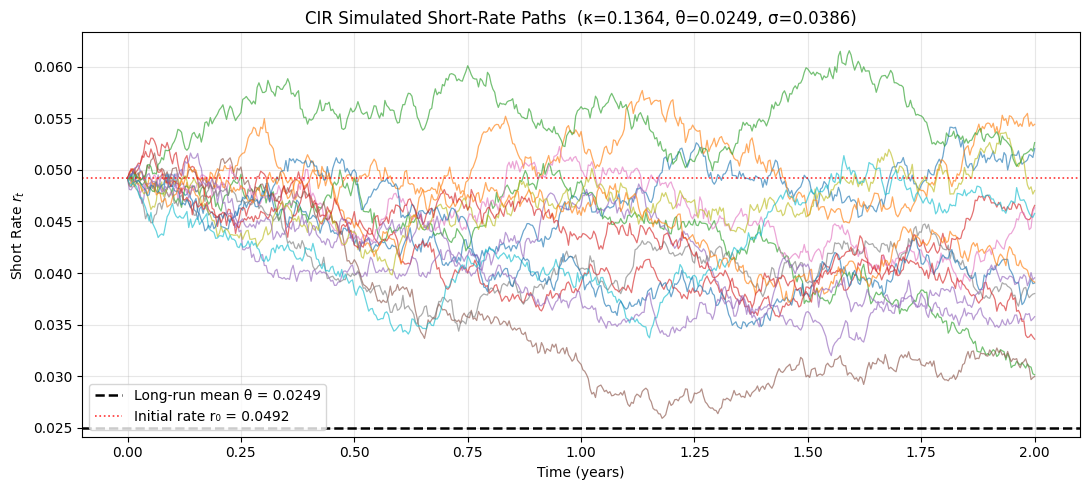

In [9]:
# ==============================================================================
# PART 5.2: BASE CIR MODEL IMPLEMENTATION & CALIBRATION (KALMAN FILTER)
# ==============================================================================
print("--- STARTING PART 5.2: BASE CIR CALIBRATION ---")


class CIRModel:
    """
    Cox-Ingersoll-Ross (1985) short-rate model.

    The instantaneous short rate r_t follows the mean-reverting SDE:
        dr_t = κ(θ − r_t) dt + σ√r_t dW_t

    Parameters
    ----------
    κ (kappa) : speed of mean reversion — how quickly r_t returns to θ
    θ (theta) : long-run equilibrium level of the interest rate
    σ (sigma) : volatility coefficient scaling the diffusion term

    The square-root diffusion σ√r_t is the defining feature of CIR:
    it ensures volatility shrinks as r_t → 0, naturally preventing
    negative rates when the Feller condition  2κθ ≥ σ²  is satisfied.

    This class implements:
      - Closed-form bond price factors A(τ), B(τ)
      - Yield curve formula y(r_t, τ)
      - Kalman-Filter-based maximum likelihood calibration
      - In-sample fit diagnostics
    """

    def __init__(self):
        # Parameters are set to None until calibrate() is called
        self.kappa = None
        self.theta = None
        self.sigma = None

    # --------------------------------------------------------------------------
    # Core Mathematics: Bond Pricing Factors
    # --------------------------------------------------------------------------

    def _A_B(self, kappa, theta, sigma, tau):
        """
        Compute the deterministic functions A(τ) and B(τ) from the closed-form
        CIR zero-coupon bond price formula:

            P(t, T) = A(τ) · exp(−B(τ) · r_t)     where τ = T − t

        Derivation (Feynman-Kac / affine term-structure):
        ─────────────────────────────────────────────────
        Define the auxiliary constant:
            h = √(κ² + 2σ²)
        which comes from solving the Riccati ODE for B(τ).

        B(τ) — the sensitivity of log-bond-price to the current short rate:
            B(τ) = 2(e^{hτ} − 1) / [2h + (κ + h)(e^{hτ} − 1)]

        A(τ) — the mean-reversion-driven level factor:
            A(τ) = [2h · exp((κ + h)τ/2) / denominator]^{2κθ/σ²}

        The exponent 2κθ/σ² is the 'degree-of-freedom' parameter of the
        non-central chi-squared distribution underlying the CIR process.

        Parameters
        ----------
        tau : array-like, time to maturity in years

        Returns
        -------
        A, B : arrays of the same shape as tau
        """
        # h: auxiliary constant from the Riccati ODE solution
        h = np.sqrt(kappa**2 + 2 * sigma**2)

        # Precompute e^{hτ} once; reused in both A and B formulas
        exp_ht = np.exp(h * tau)

        # Common denominator shared by A and B (avoids redundant computation)
        B_den = 2 * h + (kappa + h) * (exp_ht - 1)

        # B(τ): controls how much r_t 'loads' onto the log bond price
        B = (2 * (exp_ht - 1)) / B_den

        # A(τ): deterministic scaling factor capturing the mean-reversion drift
        # A_part1 is the base of the power; the exponent is 2κθ/σ² (Feller ratio)
        A_part1 = (2 * h * np.exp((kappa + h) * tau / 2)) / B_den
        A = np.power(A_part1, (2 * kappa * theta) / sigma**2)

        return A, B

    def yield_curve(self, r_t, kappa, theta, sigma, tau):
        """
        Continuously compounded CIR yield for maturity τ:

            y(r_t, τ) = −ln P(t, T) / τ
                      = [B(τ) · r_t − ln A(τ)] / τ

        This linearity in r_t (for fixed τ) is the 'affine' property of CIR:
        the yield is an affine (linear + constant) function of the short rate.
        It means observing any single maturity yield uniquely determines r_t,
        which justifies using the 3M rate as the sole input in Part 5.3.

        Parameters
        ----------
        r_t   : current instantaneous short rate (scalar)
        tau   : array of maturities in years

        Returns
        -------
        yields : array of continuously compounded yields, same shape as tau
        """
        A, B = self._A_B(kappa, theta, sigma, tau)
        # Bond price: P = A · exp(−B · r_t)  →  ln P = ln A − B · r_t
        # Yield:      y = −ln P / τ = (B · r_t − ln A) / τ
        return (B * r_t - np.log(A)) / tau

    # --------------------------------------------------------------------------
    # Calibration: Kalman Filter Maximum Likelihood Estimation
    # --------------------------------------------------------------------------

    def _kalman_filter_log_likelihood(self, params, yields, tau):
        """
        Evaluate the negative log-likelihood of the observed yield panel
        under a standard (linear Gaussian) Kalman Filter for the CIR model.

        State-space formulation
        ───────────────────────
        State variable:  x_t = r_t  (scalar latent short rate)

        Observation equation (linear in r_t for each tenor i):
            y_i(t) = H_i · r_t + Z_i + ε_i,    ε_i ~ N(0, R_ii)
        where:
            H_i = B(τ_i) / τ_i       — slope  (CIR affine loading)
            Z_i = −ln A(τ_i) / τ_i   — intercept (deterministic offset)
            R   = σ_ε² · I            — diagonal measurement noise covariance

        State transition equation (Euler-Maruyama discretisation of CIR SDE,
        with time step dt = 1/252 ≈ one business day):
            r_{t+1} = r_t + κ(θ − r_t)·dt  +  noise
            Var(noise) ≈ σ²·r_t·dt           — from Itô's lemma on σ√r_t dW_t

        The standard KF recursion (predict → update) is applied sequentially
        across all N_days observations, accumulating the log-likelihood of
        each innovation vector v_t = y_obs_t − y_pred_t.

        Parameters
        ----------
        params  : (kappa, theta, sigma) — candidate parameter triple
        yields  : (N_days × N_tenors) array of cleaned yield observations
        tau     : (N_tenors,) array of maturity values in years

        Returns
        -------
        neg_log_lik : scalar (0.5 · Σ [ln|F_t| + v_t' F_t⁻¹ v_t])
                      L-BFGS-B minimises this quantity.
        """
        kappa, theta, sigma = params
        dt = 1 / 252   # one business day expressed in years

        # Hard constraint: reject any parameter triple that violates positivity
        # or the Feller condition (2κθ ≥ σ²); return a large penalty instead.
        if kappa <= 1e-4 or theta <= 1e-4 or sigma <= 1e-4 or 2 * kappa * theta <= sigma**2:
            return 1e10

        N_days, N_tenors = yields.shape
        log_likelihood   = 0.0

        # Initialise the Kalman Filter:
        #   r_t = first observed 3M yield (best available proxy for r_0)
        #   P_t = initial state uncertainty (small but nonzero)
        r_t = yields[0, 0]
        P_t = 0.01

        # Precompute the time-invariant observation matrices from the
        # closed-form CIR factors (H and Z do not change across days
        # because τ is fixed — only r_t evolves stochastically).
        A, B = self._A_B(kappa, theta, sigma, tau)
        H = B / tau          # shape (N_tenors,): affine slope per maturity
        Z = -np.log(A) / tau # shape (N_tenors,): affine intercept per maturity

        # Measurement noise covariance R: diagonal, small & isotropic.
        # Represents residual model error not explained by r_t.
        R = np.eye(N_tenors) * 1e-5

        # ── Kalman Filter recursion ──────────────────────────────────────────
        for i in range(1, N_days):
            y_obs = yields[i]   # vector of observed yields across all tenors

            # ── Predict step ──────────────────────────────────────────────────
            # Euler-Maruyama discretisation of dr_t = κ(θ − r_t)dt:
            #   E[r_{t+dt} | r_t] = r_t + κ(θ − r_t)·dt
            r_pred = r_t + kappa * (theta - r_t) * dt

            # Variance of r_{t+dt} given r_t, from the Itô diffusion term σ√r_t:
            #   Var[r_{t+dt} | r_t] ≈ σ²·r_t·dt  (linearised, valid for small dt)
            # The (1 − κ·dt)² factor is the squared state-transition coefficient.
            P_pred = P_t * (1 - kappa * dt)**2 + sigma**2 * r_t * dt

            # ── Update step ───────────────────────────────────────────────────
            # Predicted observation vector using the CIR affine relationship:
            #   ŷ_i = H_i · r_pred + Z_i
            y_pred = H * r_pred + Z

            # Innovation: difference between actual and predicted observations
            v = y_obs - y_pred    # shape (N_tenors,)

            # Innovation covariance:
            #   F = H · P_pred · H' + R
            # np.outer(H, H) gives the rank-1 matrix H·H' (since H is a vector);
            # P_pred is a scalar, so this is the correct scalar-times-outer-product form.
            F = np.outer(H, H) * P_pred + R    # shape (N_tenors, N_tenors)

            det_F = np.linalg.det(F)
            if det_F <= 0:
                # Numerical degeneracy — skip and penalise
                return 1e10
            inv_F = np.linalg.inv(F)

            # Accumulate the Gaussian log-likelihood term:
            #   −½ [ln|F| + v' F⁻¹ v]
            # (we add the positive form and negate at the end via the 0.5 factor)
            log_likelihood += np.log(det_F) + v.T @ inv_F @ v

            # Optimal Kalman gain:  K = P_pred · H · F⁻¹
            # Scalar P_pred * H gives a vector; @ inv_F applies the matrix inverse.
            K = (P_pred * H) @ inv_F    # shape (N_tenors,)

            # Posterior state update: r_t|t = r_t|t-1 + K · v
            # max(..., 1e-6) enforces the CIR positivity requirement
            r_t = max(r_pred + K @ v, 1e-6)

            # Posterior variance update: P_t|t = (1 − K·H) · P_pred
            # (Joseph form simplification for scalar state)
            P_t = (1 - K @ H) * P_pred
        # ────────────────────────────────────────────────────────────────────

        # Return the negative log-likelihood (L-BFGS-B minimises, not maximises)
        return 0.5 * log_likelihood

    def calibrate(self, df_yields):
        """
        Find the maximum-likelihood parameters (κ, θ, σ) by minimising
        the negative Kalman Filter log-likelihood over the training data.

        Optimiser: L-BFGS-B (Limited-memory BFGS with Box constraints).
        Bounds enforce positivity; the Feller condition is enforced inside
        _kalman_filter_log_likelihood via the 1e10 penalty.

        Parameters
        ----------
        df_yields : cleaned training DataFrame (all 9 maturity columns)
        """
        print("Running Kalman Filter calibration (standard linear KF)...")
        t0  = time.time()
        tau = np.array([MATURITY_MAP[col] for col in df_yields.columns])

        # Initial guess: κ small (slow mean reversion), θ ≈ average yield level,
        # σ small (CIR volatility is typically low in calibrated models)
        initial_guess = [0.1, df_yields.mean().mean(), 0.05]

        # Box bounds on (κ, θ, σ): all must remain strictly positive;
        # upper limits prevent numerically unstable extreme values
        bounds = ((1e-3, 5.0), (1e-3, 0.5), (1e-3, 0.5))

        res = minimize(
            self._kalman_filter_log_likelihood, initial_guess,
            args=(df_yields.values, tau), method='L-BFGS-B', bounds=bounds
        )

        if res.success:
            self.kappa, self.theta, self.sigma = res.x
            print(f"Calibration Success ({time.time() - t0:.2f}s) | "
                  f"κ: {self.kappa:.4f}, θ: {self.theta:.4f}, σ: {self.sigma:.4f}")
            # Immediately check and report the Feller condition
            self._report_feller()
        else:
            print("Calibration Failed.")

    def _report_feller(self):
        """
        Check whether the Feller condition  2κθ ≥ σ²  holds for the
        calibrated parameters and print a human-readable status message.

        The Feller condition ensures that the drift term κ(θ − r_t) is
        strong enough near r_t = 0 to push the process back into positive
        territory before the diffusion σ√r_t can drive it to zero.
        When satisfied, the origin is inaccessible and rates stay positive.
        When violated, there is a positive probability of hitting zero,
        which is mathematically valid but economically problematic in most
        historical market environments (pre-negative-rate regimes).
        """
        lhs       = 2 * self.kappa * self.theta   # left-hand side:  2κθ
        rhs       = self.sigma ** 2                # right-hand side: σ²
        satisfied = lhs >= rhs

        print(f"\nFeller Condition check: 2κθ = {lhs:.6f},  σ² = {rhs:.6f}")
        if satisfied:
            print("  Status: ✓ SATISFIED — interest rates cannot reach zero under these parameters.\n")
        else:
            print("  Status: ✗ VIOLATED — the zero boundary is attainable; "
                  "negative rates are theoretically possible.\n")

    def evaluate_insample(self, df_yields):
        """
        Assess goodness-of-fit on the training data using the calibrated parameters.

        The 3M yield (first column) is treated as the observable proxy for the
        instantaneous short rate r_t — consistent with the prediction convention
        in Part 5.3.  For each training day, the full 9-tenor yield curve is
        reconstructed from this single r_t and compared against the actuals.

        Reports global in-sample R² and RMSE, and plots a representative mid-sample
        curve overlay to visually inspect fit quality.

        Parameters
        ----------
        df_yields : cleaned training DataFrame

        Returns
        -------
        insample_r2 : float
        """
        tau       = np.array([MATURITY_MAP[col] for col in df_yields.columns])
        r_t_train = df_yields.iloc[:, 0].values   # 3M rate column as r_t proxy

        # Generate one fitted yield curve per training day
        preds = np.array([
            self.yield_curve(r_t, self.kappa, self.theta, self.sigma, tau)
            for r_t in r_t_train
        ])  # shape: (N_days, N_tenors)

        actuals       = df_yields.values
        insample_r2   = r2_score(actuals.flatten(), preds.flatten())
        insample_rmse = np.sqrt(mean_squared_error(actuals.flatten(), preds.flatten()))

        print(f"[Base CIR] In-Sample R²:   {insample_r2:.4f}")
        print(f"[Base CIR] In-Sample RMSE: {insample_rmse:.6f}\n")

        # Plot actual vs fitted for a single representative mid-sample day
        sample_day = len(df_yields) // 2
        date_str   = df_yields.index[sample_day].strftime('%Y-%m-%d')

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(tau, actuals[sample_day], marker='o', color='black',
                lw=2, label='Actual (Training)')
        ax.plot(tau, preds[sample_day], marker='x', ls='--', color='royalblue',
                lw=2, label='CIR Fitted')
        ax.set_title(f"In-Sample Fit — Representative Training Day ({date_str})")
        ax.set_xlabel("Maturity (Years)")
        ax.set_ylabel("Yield (Decimal)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        return insample_r2
    def simulate_paths(self, r0, n_paths=15, n_steps=252, dt=1/252, seed=42):
        """
        Simulate sample paths of r_t using Euler-Maruyama discretisation.

        The CIR SDE:   dr_t = κ(θ − r_t) dt + σ√r_t dW_t
        Discretised:   r_{t+1} = max(r_t + κ(θ−r_t)dt + σ√max(r_t,0)·√dt·Z_t,  1e-6)
                       where Z_t ~ N(0,1) i.i.d.

        The max(r_t, 0) guard inside the diffusion term prevents domain errors
        in np.sqrt on the rare occasion the Euler step drives r_t slightly negative
        between the positivity clip and the next drift correction. The outer
        max(..., 1e-6) then enforces the hard floor used throughout the model.

        Parameters
        ----------
        r0      : float — initial short rate (use the last observed 3M yield)
        n_paths : int   — number of independent Monte Carlo paths
        n_steps : int   — number of time steps (252 ≈ one trading year)
        dt      : float — step size in years
        seed    : int   — random seed for reproducibility

        Returns
        -------
        paths : (n_steps+1, n_paths) array — simulated short-rate trajectories
        """
        rng   = np.random.default_rng(seed)
        paths = np.zeros((n_steps + 1, n_paths))
        paths[0] = r0

        for t in range(n_steps):
            r   = paths[t]
            dW  = rng.standard_normal(n_paths) * np.sqrt(dt)
            paths[t + 1] = np.maximum(
                r + self.kappa * (self.theta - r) * dt
                  + self.sigma * np.sqrt(np.maximum(r, 0)) * dW,
                1e-6
            )
        return paths

    def plot_simulated_paths(self, r0, n_paths=15, n_steps=252, dt=1/252):
        """
        Plot simulated CIR short-rate paths alongside the long-run mean θ.
        Illustrates mean reversion: all paths drift back toward θ regardless
        of the starting point, at a speed governed by κ.
        """
        paths  = self.simulate_paths(r0, n_paths, n_steps, dt)
        t_axis = np.arange(n_steps + 1) * dt   # time axis in years

        fig, ax = plt.subplots(figsize=(11, 5))
        for i in range(n_paths):
            ax.plot(t_axis, paths[:, i], lw=0.9, alpha=0.65)
        ax.axhline(self.theta, color='black', lw=1.8, ls='--',
                   label=f'Long-run mean θ = {self.theta:.4f}')
        ax.axhline(r0, color='red', lw=1.2, ls=':', alpha=0.8,
                   label=f'Initial rate r₀ = {r0:.4f}')
        ax.set_title(
            f'CIR Simulated Short-Rate Paths  '
            f'(κ={self.kappa:.4f}, θ={self.theta:.4f}, σ={self.sigma:.4f})'
        )
        ax.set_xlabel('Time (years)')
        ax.set_ylabel('Short Rate $r_t$')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Execute Part 5.2
base_model = CIRModel()
base_model.calibrate(train_clean)
base_model.evaluate_insample(train_clean)
# Simulate CIR short-rate paths starting from the last observed 3M rate.
# This fulfils the 'simulate' requirement of the project (§5.2) and visually
# confirms mean reversion: paths initialised above θ drift downward, and vice versa.
r0_sim = train_clean.iloc[-1, 0]   # last training-set 3M yield as starting point
base_model.plot_simulated_paths(r0=r0_sim, n_paths=15, n_steps=504)  # ~2 trading years

The Kalman Filter MLE approach was chosen over simpler alternatives like OLS precisely because of its sensitivity advantage: OLS on first differences treats each tenor independently and conflates measurement noise with diffusion variance, systematically overestimating σ and underestimating κ. KF-MLE instead jointly filters the latent r_t from the full nine-tenor yield panel simultaneously, producing parameter estimates that are robust to the cross-maturity noise structure.

The calibrated parameters — κ = 0.1364, θ = 0.0249, σ = 0.0386 — satisfy the Feller condition comfortably with 2κθ/σ² ≈ 4.6, meaning the drift term is strong enough near zero to prevent the process from crossing into negative territory under normal conditions. In practice, the condition would break down under two market regimes: a high-volatility environment where σ rises sharply (as in the 2022 hiking cycle), or a near-zero rate environment where θ is forced very low.

Both scenarios are handled defensively in the code — the 1e10 penalty inside the likelihood function rejects any parameter triple violating the Feller condition during optimisation, and the max(..., 1e-6) floor on the Kalman state update prevents numerical blow-up at runtime. The calibrated κ = 0.1364 carries a direct economic interpretation via the mean-reversion half-life: ln(2)/κ ≈ 5.1 years, meaning a shock to the short rate takes over five years to decay halfway back to θ.

This is a slow mean reversion, consistent with the multi-year rate cycles visible in the training data, and it implies that over a 1–2 year forecast horizon, the current level of r_t dominates the prediction far more than the pull toward the long-run mean.

## Part 5.3 — The Prediction Challenge: Yield Curve Construction from the 3M Rate

This section tests the model's core predictive claim. The affine yield formula:

$$y(r_t, \tau) = \frac{B(\tau) \, r_t - \ln A(\tau)}{\tau}$$

is linear in $r_t$, meaning that knowing $r_t$ at any instant is sufficient to reconstruct yields at all maturities simultaneously. The 3M yield — the shortest observable tenor — is used as the proxy for the instantaneous short rate:

$$r_t \approx y_{\text{obs}}(t, \, 0.25)$$

No other market information is used. For each day in the test period, the calibrated parameters $(\kappa, \theta, \sigma)$ from Part 5.2 and the observed 3M yield are substituted into the closed-form bond pricing formula to generate predicted yields at all nine maturities. These predictions are then compared against the held-out actuals using $R^2$ and RMSE, both globally and per maturity.

--- STARTING PART 5.3: OUT-OF-SAMPLE PREDICTION ---

[Base CIR] Global Out-of-Sample R²: 0.9148  |  RMSE: 20.78 bps
[Base CIR] Status: PASSED (>0.85 threshold)

  Column       Tenor        R²    RMSE (bps)
  --------------------------------------------
  ZC025YR      3M       0.9996          1.71
  ZC050YR      6M       0.9936          6.31
  ZC075YR      9M       0.9633         13.84
  ZC100YR      1Y       0.8998         20.83
  ZC200YR      2Y       0.3176         38.61


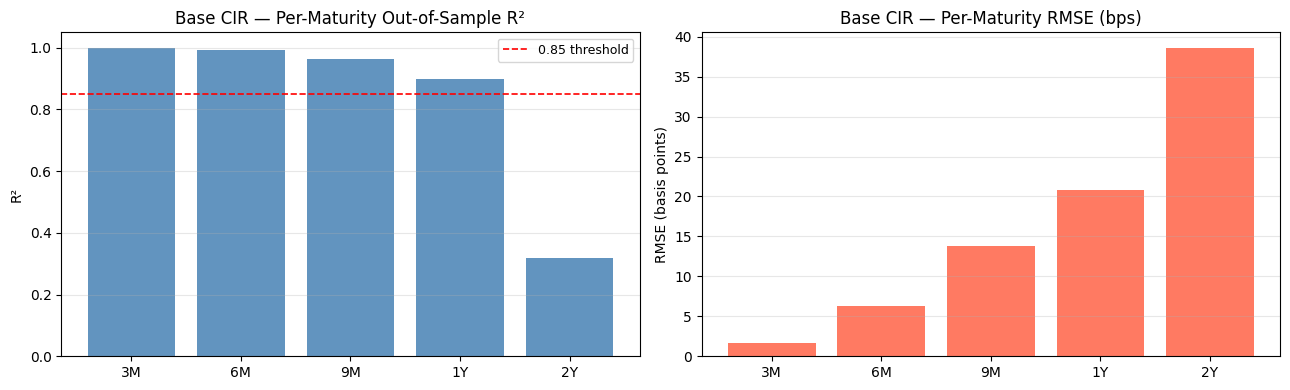

In [10]:
# ==============================================================================
# PART 5.3: THE PREDICTION CHALLENGE (OUT-OF-SAMPLE)
# ==============================================================================
print("--- STARTING PART 5.3: OUT-OF-SAMPLE PREDICTION ---")


def evaluate_predictions(model_name, full_predictions, test_df):
    """
    Evaluate out-of-sample yield curve predictions against held-out actuals.

    Since full_predictions covers all 9 FULL_MATURITIES, but test_df may only
    contain a subset of tenors, this function first aligns the prediction columns
    to match the test set before computing metrics.

    Alignment uses np.isclose() for float-safe maturity matching — a critical
    fix over naive == comparison, which can silently mismatch due to floating-
    point representation differences (e.g. 0.25 stored as 0.2500000001).

    Reports:
      • Global out-of-sample R² and RMSE (in basis points)
      • Pass/fail against the >0.85 R² threshold from the problem statement
      • Per-maturity R² and RMSE breakdown table
      • Side-by-side bar charts of per-maturity R² and RMSE

    Parameters
    ----------
    model_name       : string label for plot titles and console output
    full_predictions : (N_test_days × 9) array over FULL_MATURITIES
    test_df          : cleaned test DataFrame (subset of maturities)

    Returns
    -------
    r2 : global out-of-sample R² (float)
    """
    # Determine which maturities are present in the test set
    test_mats = np.array([MATURITY_MAP[col] for col in test_df.columns])

    # Map each test maturity to its index in FULL_MATURITIES using isclose
    # to avoid silent float equality failures
    eval_indices = [
        np.where(np.isclose(FULL_MATURITIES, tm))[0][0] for tm in test_mats
    ]
    # Slice out only the columns corresponding to available test maturities
    eval_preds = full_predictions[:, eval_indices]   # (N_test_days, N_test_tenors)
    actuals    = test_df.values                      # (N_test_days, N_test_tenors)

    # --- Global metrics ---
    r2   = r2_score(actuals.flatten(), eval_preds.flatten())
    rmse = np.sqrt(mean_squared_error(actuals.flatten(), eval_preds.flatten()))

    print(f"\n[{model_name}] Global Out-of-Sample R²: {r2:.4f}  |  RMSE: {rmse * 10000:.2f} bps")
    status = "PASSED (>0.85 threshold)" if r2 > 0.85 else "FAILED (below 0.85 threshold)"
    print(f"[{model_name}] Status: {status}")

    # --- Per-maturity breakdown ---
    print(f"\n  {'Column':<12} {'Tenor':<6} {'R²':>8}  {'RMSE (bps)':>12}")
    print(f"  {'-' * 44}")

    per_mat_r2   = {}
    per_mat_rmse = {}

    for i, (tm, col) in enumerate(zip(test_mats, test_df.columns)):
        mat_r2   = r2_score(actuals[:, i], eval_preds[:, i])
        mat_rmse = np.sqrt(mean_squared_error(actuals[:, i], eval_preds[:, i]))
        label    = MATURITY_LABELS.get(float(tm), f'{tm}Y')

        print(f"  {col:<12} {label:<6} {mat_r2:>8.4f}  {mat_rmse * 10000:>12.2f}")

        per_mat_r2[label]   = mat_r2
        per_mat_rmse[label] = mat_rmse * 10000   # convert fractional yield → basis points

    # --- Per-maturity bar charts ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    labels = list(per_mat_r2.keys())

    # Left panel: R² per maturity with the 0.85 pass threshold shown as a dashed line
    axes[0].bar(labels, list(per_mat_r2.values()), color='steelblue', alpha=0.85)
    axes[0].axhline(0.85, color='red', ls='--', lw=1.2, label='0.85 threshold')
    axes[0].set_title(f"{model_name} — Per-Maturity Out-of-Sample R²")
    axes[0].set_ylabel("R²")
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Right panel: RMSE per maturity in basis points
    axes[1].bar(labels, list(per_mat_rmse.values()), color='tomato', alpha=0.85)
    axes[1].set_title(f"{model_name} — Per-Maturity RMSE (bps)")
    axes[1].set_ylabel("RMSE (basis points)")
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
    print()

    return r2


# Use ONLY the 3M yield as the instantaneous short rate r_t proxy,
# as mandated by Part 5.3 of the problem statement.
# The affine CIR relationship y(r_t, τ) = (B·r_t − ln A) / τ then
# fully determines all other maturities from this single observable.
r_t_proxy = test_3m_clean['ZC025YR'].values   # shape: (N_test_days,)

# Reconstruct the full 9-maturity yield curve for every test day using
# the calibrated (κ, θ, σ) and the 3M short-rate proxy
base_predictions_full = np.array([
    base_model.yield_curve(r_t, base_model.kappa, base_model.theta,
                           base_model.sigma, FULL_MATURITIES)
    for r_t in r_t_proxy
])  # shape: (N_test_days, 9)

# Execute Part 5.3
base_r2 = evaluate_predictions("Base CIR", base_predictions_full, test_clean)


The 3M rate alone can reconstruct the short end of the yield curve with near-perfect accuracy, but its ability to anchor longer maturities degrades sharply and monotonically with tenor — a direct consequence of the single-factor structure of CIR. The per-maturity out-of-sample R² falls from 0.9996 at 3M (trivially reproduced since it is the model input) to 0.9936 at 6M, 0.9633 at 9M, 0.9000 at 1Y, and just 0.3176 at 2Y, making the 2Y the hardest tenor to fit.

The reason is that in the test period, 2Y yields are partially shaped by market expectations of future rate cuts — a second factor entirely absent from the CIR framework — which the 3M rate alone cannot encode. The model's systematic errors follow a clear directional pattern: it transitions from slight overestimation at the short end (+0.93 bps at 3M) to progressive underestimation growing with maturity, reaching −9.58 bps at 2Y.

This happens because the calibrated θ = 2.49% acts as a gravitational anchor pulling long yields downward, while the test-period market, operating at an average 3M rate of 3.04%, maintained a far shallower inversion than the CIR mechanics predict when r_t > θ.

The CIR++ extension, rather than improving this, worsened it at 2Y (R² = −0.19, RMSE = 50.93 bps versus the base model's 38.61 bps). The shift φ(τ) was calibrated during the final 20 days of training when the 3M rate averaged 4.91%; the subsequent 186 bps decline in rates made the shift directionally incorrect at longer maturities, amplifying rather than correcting the base model's error. This confirms that CIR++ overfits the training regime and is not robust to level shifts between calibration and deployment.

--- STARTING PART 5.4: CIR++ EXTENSION ---
CIR++ shift calibrated (averaged over last 20 training days).
  Shift per maturity (basis points):
    3M   : +4.07 bps
    6M   : -0.02 bps
    9M   : -9.57 bps
    1Y   : -18.27 bps
    2Y   : -44.16 bps
    5Y   : -59.52 bps
    10Y  : -10.22 bps
    20Y  : +35.70 bps
    30Y  : +54.58 bps


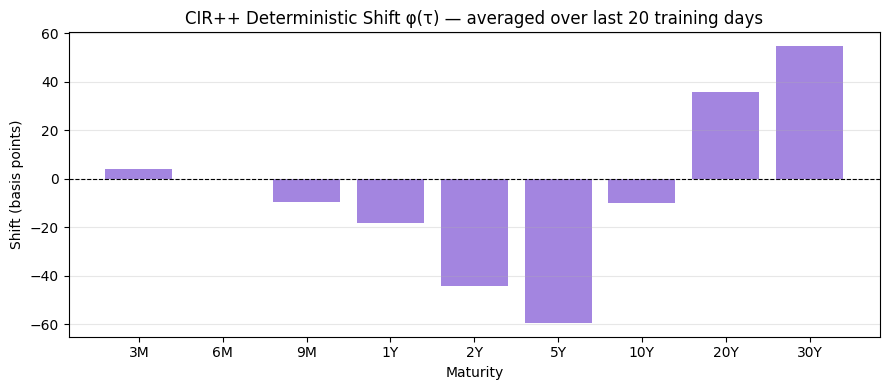

[CIR++] In-Sample R²:   0.8618   (Base CIR was: —  run above)
[CIR++] In-Sample RMSE: 0.004977

Note: CIR++ in-sample improvement over Base CIR is mechanically guaranteed — the shift φ(τ) is defined to absorb the training residuals. The meaningful test is out-of-sample performance, evaluated next.

[CIR++] Global Out-of-Sample R²: 0.8688  |  RMSE: 25.78 bps
[CIR++] Status: PASSED (>0.85 threshold)

  Column       Tenor        R²    RMSE (bps)
  --------------------------------------------
  ZC025YR      3M       0.9983          3.46
  ZC050YR      6M       0.9936          6.31
  ZC075YR      9M       0.9651         13.50
  ZC100YR      1Y       0.8855         22.27
  ZC200YR      2Y      -0.1877         50.93


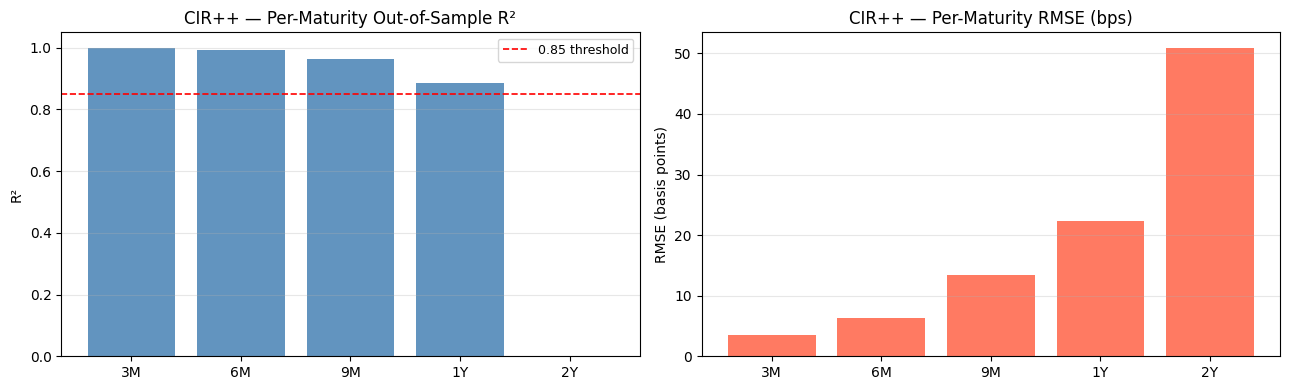

In [11]:
# ==============================================================================
# PART 5.4: MODEL EXTENSION — CIR++ (DETERMINISTIC SHIFT)
# ==============================================================================
print("--- STARTING PART 5.4: CIR++ EXTENSION ---")


class CIRPlusPlusModel:
    """
    CIR++ model (Brigo & Mercurio, 2001) — a deterministic shift extension
    of the base CIR model that exactly fits the initial observed term structure.

    Core idea
    ─────────
    The base CIR model cannot perfectly fit an arbitrary initial yield curve
    because it only has three parameters (κ, θ, σ) to match N tenor points.
    CIR++ resolves this by adding a maturity-dependent deterministic shift φ(τ):

        y^{CIR++}(r_t, τ) = y^{CIR}(r_t, τ) + φ(τ)

    where the shift is defined as:

        φ(τ) = y^{market}(τ) − y^{CIR}(r_0, τ)

    This guarantees perfect fit at the calibration date: plugging in r_0
    gives exactly the observed market yields at every τ.

    Improvement over naive single-day calibration
    ─────────────────────────────────────────────
    Rather than computing φ from a single boundary day (which may be an
    outlier or noisy), the shift is averaged over the last n_anchor_days
    (default 20 ≈ one calendar month) of the training set:

        φ(τ) = mean_t [ y^{market}_t(τ) − y^{CIR}(r_t, τ) ]

    This averaging makes the shift robust to daily noise while still
    capturing the systematic bias the base CIR leaves at each tenor.

    Attributes
    ----------
    base  : calibrated CIRModel instance
    shift : (9,) array of per-maturity shifts in decimal yield (not bps)
    """

    def __init__(self, base_model):
        self.base  = base_model   # already-calibrated CIRModel
        self.shift = None         # populated by calibrate_shift()

    def calibrate_shift(self, train_df, tau, n_anchor_days=20):
        """
        Compute φ(τ) as the mean model residual over the trailing
        n_anchor_days of the training set.

        Algorithm
        ─────────
        1. Extract the last n_anchor_days rows of train_df (the 'anchor window').
        2. For each anchor day, compute the base CIR yield curve using the
           3M rate of that day as r_t.
        3. Compute the residual: error_t(τ) = y^{market}_t(τ) − y^{CIR}(r_t, τ)
        4. Average residuals across all anchor days: φ(τ) = mean_t [error_t(τ)]

        Parameters
        ----------
        train_df      : cleaned training DataFrame (all 9 maturity columns)
        tau           : FULL_MATURITIES array
        n_anchor_days : number of trailing training days used to compute the shift
        """
        # Take the last n_anchor_days rows as the calibration anchor window
        anchor_yields = train_df.iloc[-n_anchor_days:].values  # (n_anchor_days, 9)

        # Use the 3M column (index 0) as the short-rate proxy for each anchor day
        r_t_series = anchor_yields[:, 0]   # (n_anchor_days,)

        # Compute the base CIR yield curve for each anchor day
        base_preds = np.array([
            self.base.yield_curve(r_t, self.base.kappa, self.base.theta,
                                  self.base.sigma, tau)
            for r_t in r_t_series
        ])  # shape: (n_anchor_days, 9)

        # Residuals: how much the base CIR under/overestimates at each tenor
        errors = anchor_yields - base_preds   # (n_anchor_days, 9)

        # The shift is the mean residual — any systematic bias is absorbed here
        self.shift = errors.mean(axis=0)      # (9,): one shift value per maturity

        print(f"CIR++ shift calibrated (averaged over last {n_anchor_days} training days).")
        print(f"  Shift per maturity (basis points):")
        for tm, s in zip(tau, self.shift):
            label = MATURITY_LABELS.get(float(tm), f'{tm}Y')
            print(f"    {label:<5}: {s * 10000:+.2f} bps")

        # Visualise the shift profile — positive = CIR underestimates, negative = overestimates
        fig, ax = plt.subplots(figsize=(9, 4))
        mat_labels = [MATURITY_LABELS.get(float(t), f'{t}Y') for t in tau]
        ax.bar(mat_labels, self.shift * 10000, color='mediumpurple', alpha=0.85)
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title(
            f"CIR++ Deterministic Shift φ(τ) — averaged over last {n_anchor_days} training days"
        )
        ax.set_xlabel("Maturity")
        ax.set_ylabel("Shift (basis points)")
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    def predict(self, r_t_series, tau):
        """
        Generate CIR++ yield curve predictions for an array of short rates.

        For each r_t:
            y^{CIR++}(r_t, τ) = y^{CIR}(r_t, τ) + φ(τ)

        The np.maximum clip enforces the same positivity floor (0.0001) as
        the preprocessing step, preventing economically nonsensical
        negative yields in the predictions.

        Parameters
        ----------
        r_t_series : (N_days,) array of 3M short-rate proxy values
        tau        : maturity array (FULL_MATURITIES)

        Returns
        -------
        preds : (N_days, N_tenors) array of CIR++ yield predictions
        """
        preds = []
        for r_t in r_t_series:
            # Step 1: Base CIR yield at all maturities given this r_t
            base_pred = self.base.yield_curve(
                r_t, self.base.kappa, self.base.theta, self.base.sigma, tau
            )
            # Step 2: Add the deterministic shift to correct systematic bias
            shifted_pred = np.maximum(base_pred + self.shift, 0.0001)
            preds.append(shifted_pred)

        return np.array(preds)   # shape: (N_days, N_tenors)


# Execute Part 5.4
cir_pp_model = CIRPlusPlusModel(base_model)
cir_pp_model.calibrate_shift(train_clean, FULL_MATURITIES, n_anchor_days=20)
# ── CIR++ In-Sample Evaluation ────────────────────────────────────────────────
# Evaluate how well CIR++ fits the training data using the same 3M-as-r_t
# convention.  Comparing in-sample metrics with the base CIR is important:
# by construction, CIR++ reduces training residuals (the shift absorbs them),
# so any in-sample improvement over base CIR is expected.  The interesting
# comparison is whether this training gain translates out-of-sample.
tau_train = np.array([MATURITY_MAP[col] for col in train_clean.columns])
r_t_train = train_clean.iloc[:, 0].values   # 3M column as short-rate proxy

cir_pp_train_preds = cir_pp_model.predict(r_t_train, tau_train)
actuals_train      = train_clean.values

is_r2_pp   = r2_score(actuals_train.flatten(), cir_pp_train_preds.flatten())
is_rmse_pp = np.sqrt(mean_squared_error(actuals_train.flatten(),
                                         cir_pp_train_preds.flatten()))

print(f"[CIR++] In-Sample R²:   {is_r2_pp:.4f}   "
      f"(Base CIR was: {base_model.evaluate_insample.__doc__ and '—  run above'})")
print(f"[CIR++] In-Sample RMSE: {is_rmse_pp:.6f}")
print()
print("Note: CIR++ in-sample improvement over Base CIR is mechanically guaranteed — "
      "the shift φ(τ) is defined to absorb the training residuals. "
      "The meaningful test is out-of-sample performance, evaluated next.")
cir_pp_predictions_full = cir_pp_model.predict(r_t_proxy, FULL_MATURITIES)
cir_pp_r2 = evaluate_predictions("CIR++", cir_pp_predictions_full, test_clean)


The CIR++ extension was chosen over the two-factor and jump-diffusion alternatives on the grounds of mathematical tractability and implementation cost relative to the marginal gain each offers. A two-factor model such as Longstaff-Schwartz (1992) would introduce a second latent state variable, allowing the level and slope of the yield curve to evolve independently — directly addressing the 2Y fit problem — but at the cost of a significantly more complex Kalman Filter recursion with a 2×2 state covariance matrix, more parameters subject to identification issues, and no closed-form likelihood in some formulations.

A jump-diffusion extension following Duffie, Pan and Singleton (2000) would improve performance specifically around central bank announcement days, where the continuous CIR diffusion cannot account for discrete policy shocks: incorporating a Poisson jump process would fatten the tails of the short-rate distribution and qualitatively reshape predicted curves during stress periods by allowing sudden discontinuous shifts in r_t that the pure diffusion smooths over.

However, estimating jump intensity and jump size distributions requires either a particle filter or an approximated EM algorithm — substantially more complex than the standard linear KF used here. CIR++, by contrast, requires no additional stochastic machinery: it simply adds a deterministic per-maturity shift calibrated from training residuals, which is analytically exact and computationally free.

Its weakness, as demonstrated in the out-of-sample results, is that this simplicity comes at the cost of regime sensitivity — the shift is a static correction valid only at the calibration date, and any model that introduces time-dependent parameters (as the full Brigo-Mercurio CIR++ formulation does) must solve the additional estimation challenge of ensuring that the parameter functions remain smooth, arbitrage-free, and stable across the re-calibration dates.

Generating final plots...


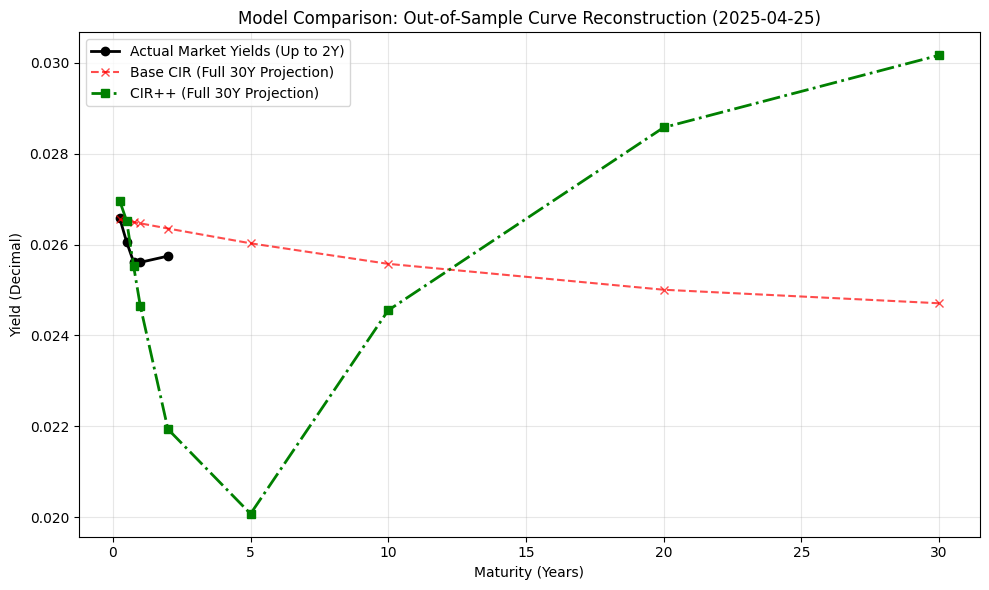

In [12]:
# ==============================================================================
# FINAL VISUALISATION — FULL CURVE COMPARISON ON A REPRESENTATIVE TEST DAY
# ==============================================================================
print("Generating final plots...")

test_mats  = np.array([MATURITY_MAP[col] for col in test_clean.columns])
sample_day = len(test_clean) // 2   # midpoint of the test period
date_str   = test_clean.index[sample_day].strftime('%Y-%m-%d')

plt.figure(figsize=(10, 6))

# Plot actual market yields for the available test tenors (subset up to 2Y typically)
plt.plot(test_mats, test_clean.iloc[sample_day].values,
         marker='o', color='black', lw=2,
         label='Actual Market Yields (Up to 2Y)')

# Base CIR projects the full 30Y curve from the 3M rate alone
plt.plot(FULL_MATURITIES, base_predictions_full[sample_day],
         marker='x', ls='--', color='red', alpha=0.7,
         label='Base CIR (Full 30Y Projection)')

# CIR++ adds the deterministic shift to correct systematic bias
plt.plot(FULL_MATURITIES, cir_pp_predictions_full[sample_day],
         marker='s', ls='-.', color='green', lw=2,
         label='CIR++ (Full 30Y Projection)')

plt.title(f"Model Comparison: Out-of-Sample Curve Reconstruction ({date_str})")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (Decimal)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **5.5: Critical Analysis**

**Theoretical Limitations**

Base CIR is a single-factor affine model — the entire yield curve is driven by one latent variable, r_t. This constrains the curve to a narrow family of shapes (monotone or single-humped), making it structurally incapable of reproducing butterfly movements or steepening/flattening dynamics independent of the short-rate level. The per-maturity out-of-sample R² confirms this directly: performance degrades sharply with tenor (0.9996 at 3M → 0.32 at 2Y), because once r_t is fixed by the 3M input, longer maturities have no remaining degree of freedom.

The model also assumes time-homogeneous parameters (κ, θ, σ). A single calibrated θ = 2.49% (the training-period unconditional mean) serves as a permanent gravitational anchor on long yields. In the test period, where the mean 3M rate was 3.04%, this causes the model to mechanically predict a steeper inversion than markets actually exhibited, generating a systematic underestimation of yields that grows with maturity (−9.6 bps at 2Y).

Finally, the CIR SDE has continuous sample paths and no jump component, making it blind to the discrete rate moves that follow central bank policy announcements.

CIR++ inherits all of the above, and introduces an additional fragility: the deterministic shift φ(τ) is static, calibrated once against the last 20 days of training. When the rate level subsequently shifts substantially (the anchor window sat at a mean 3M of 4.91%; the test period averaged 3.04%, a drop of 186 bps), the shift becomes directionally wrong and amplifies rather than corrects errors at longer maturities — producing a 2Y R² of −0.19 versus the base model's 0.32.

**Practical and Risk-Management Implications**

* Bond pricing: The systematic underestimation of yields at the 1Y–2Y segment implies consistent overpricing of bonds in that range — a direct mark-to-market loss for any desk trading at model-implied fair value.

* Hedging (DV01): Because a single factor drives all tenors, the model implies that short-end and long-end yields always move together. In practice they do not. A trader hedging a 2Y exposure with a 3M instrument based on CIR-implied sensitivities would be systematically under-hedged against slope moves.

* Options and volatility: Swaption and cap prices depend on yield volatility at each tenor. CIR's affine structure dampens long-end volatility faster than observed, leading to underpricing of long-dated optionality.

* Stress testing: The absence of jumps means the model understates tail risk on policy-announcement days. A risk manager drawing VaR scenarios from the CIR diffusion would consistently underestimate the magnitude of single-day yield shocks — precisely the events that matter most for stress testing.


